## Importando el dataset.

Vamos a importar el dataset de 'Seoul Bike Sharing Demand' del repositorio de Machine Learning de UC Irvine, que [podemos encontrar aquí](https://archive.ics.uci.edu/dataset/560/seoul+bike+sharing+demand) siguiendo la documentación de importación que en dicha URL se encuentra.

In [62]:
from ucimlrepo import fetch_ucirepo 
import pandas as pd 
# fetch dataset 
seoul_bike_sharing_demand = fetch_ucirepo(id=560) 
  
# data (as pandas dataframes) 
X = seoul_bike_sharing_demand.data.features 
y = seoul_bike_sharing_demand.data.targets 
  
# metadata 
print(seoul_bike_sharing_demand.metadata) 
  
# variable information 
print(seoul_bike_sharing_demand.variables) 


seoul_bike_sharing_demand_df = pd.concat([seoul_bike_sharing_demand.data.features, seoul_bike_sharing_demand.data.targets], axis=1)


{'uci_id': 560, 'name': 'Seoul Bike Sharing Demand', 'repository_url': 'https://archive.ics.uci.edu/dataset/560/seoul+bike+sharing+demand', 'data_url': 'https://archive.ics.uci.edu/static/public/560/data.csv', 'abstract': 'The dataset contains count of public bicycles rented per hour in the Seoul Bike Sharing System, with corresponding weather data and holiday information', 'area': 'Business', 'tasks': ['Regression'], 'characteristics': ['Multivariate'], 'num_instances': 8760, 'num_features': 13, 'feature_types': ['Integer', 'Real'], 'demographics': [], 'target_col': ['Functioning Day'], 'index_col': None, 'has_missing_values': 'no', 'missing_values_symbol': None, 'year_of_dataset_creation': 2020, 'last_updated': 'Mon Feb 05 2024', 'dataset_doi': '10.24432/C5F62R', 'creators': [], 'intro_paper': None, 'additional_info': {'summary': 'Currently Rental bikes are introduced in many urban cities for the enhancement of mobility comfort. It is important to make the rental bike available and a

Vamos a limpiar el dataset usando limpieza_de_dataset.py

In [63]:
from clean_dataset import cleanDataFrame


clean_df = cleanDataFrame(seoul_bike_sharing_demand_df)

clean_df.make_date()
clean_df.make_weekend()

seoul_bike_sharing_demand_df = clean_df.dataframe


Ahora haremos un EDA inicial con 'Profile Report'.

In [64]:
import pandas as pd
from ydata_profiling import ProfileReport

profile = ProfileReport(seoul_bike_sharing_demand_df, title="Seoul Bike EDA Report")
profile.to_notebook_iframe()
# profile.to_file("seoul_bike_eda_report.html")

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]

100%|██████████| 17/17 [00:00<00:00, 169769.45it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Además del EDA inicial queremos ilustrar las siguientes observaciones:

/tmp/ipykernel_10092/3453683050.py:26: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  sns.barplot(data=seoul_bike_sharing_demand_df,
/tmp/ipykernel_10092/3453683050.py:26: UserWarning: The palette list has more values (4) than needed (2), which may not be intended.
  sns.barplot(data=seoul_bike_sharing_demand_df,
/tmp/ipykernel_10092/3453683050.py:26: UserWarning: 
The palette list has fewer values (4) than needed (12) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(data=seoul_bike_sharing_demand_df,
/tmp/ipykernel_10092/3453683050.py:26: UserWarning: 
The palette list has fewer values (4) than needed (7) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(data=seoul_bike_sharing_demand_df,


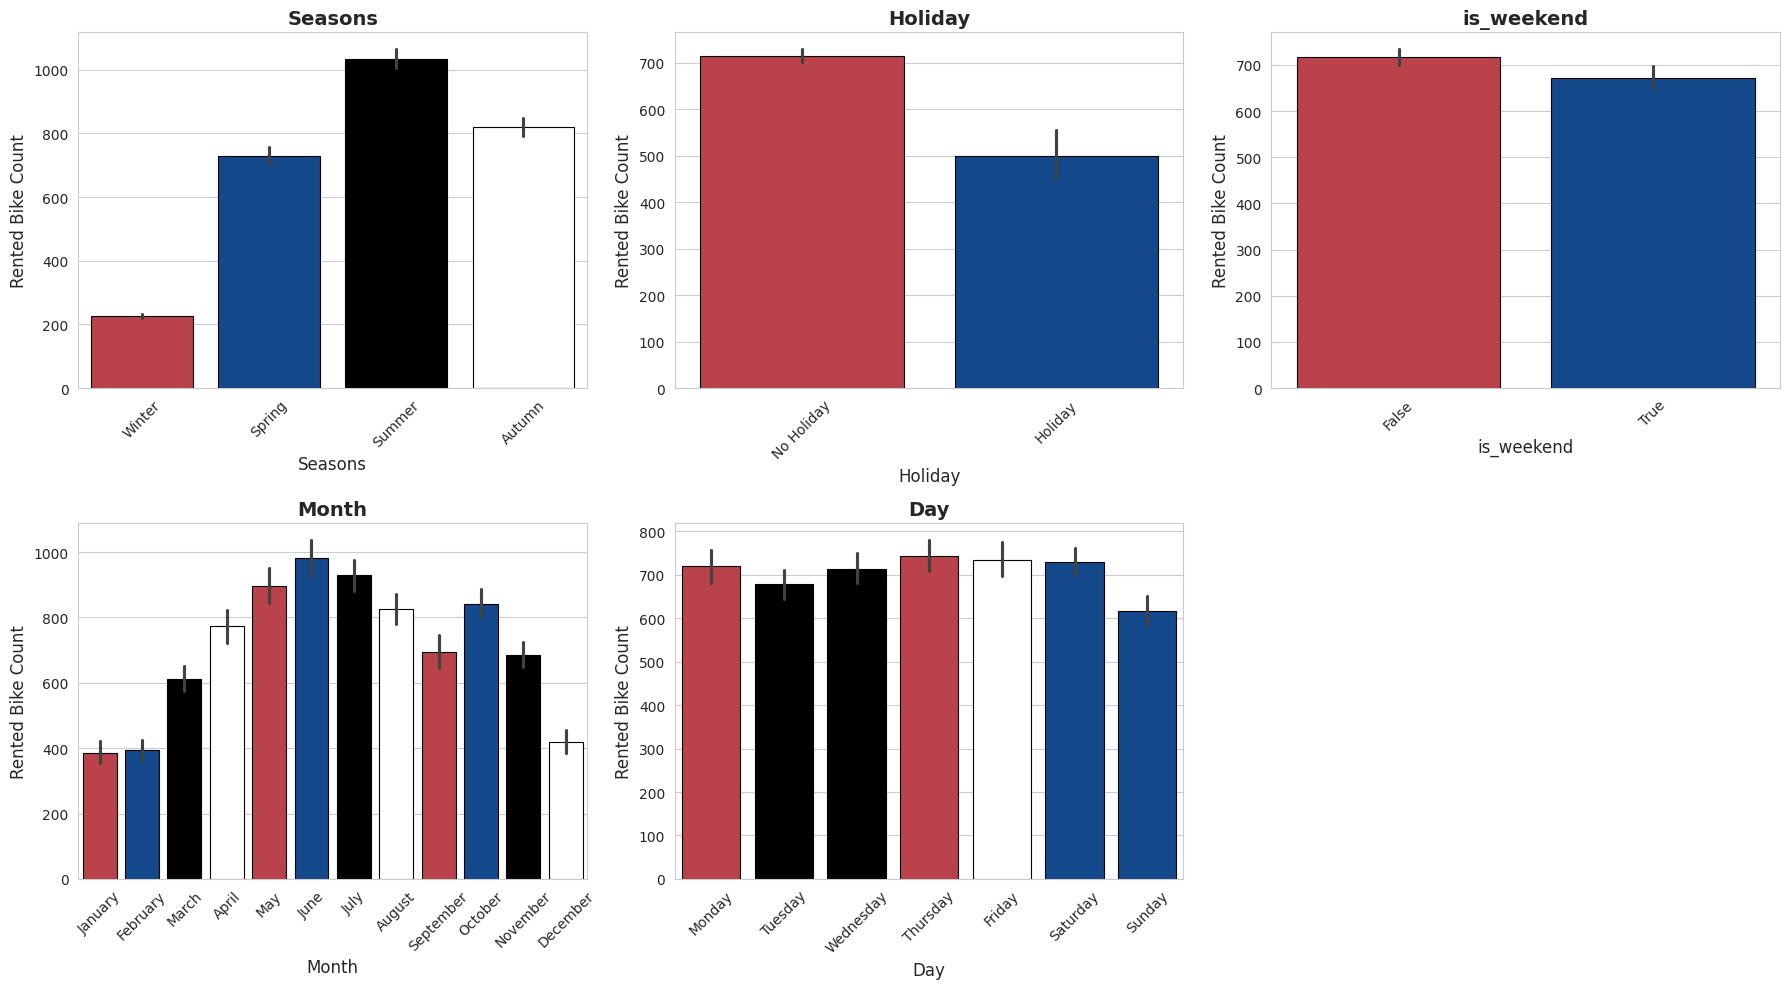

In [65]:
%matplotlib inline
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

sns.set_style("whitegrid")
palette = ["#CD2E3A", "#0047A0", "#000000", "#FFFFFF"]   # usé los colores de la bandera de Corea del Sur

categorical_columns = ["Seasons", "Holiday", "is_weekend", "Month", "Day"]

day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(categorical_columns):
    if col == 'Day':
        order = day_order
    elif col == 'Month':
        order = month_order
    else:
        order = None   

    sns.barplot(data=seoul_bike_sharing_demand_df,
                x=col, y='Rented Bike Count',
                hue=col, palette=palette, legend=False,
                order=order,                    
                edgecolor='black', linewidth=0.8,
                ax=axes[i])
    axes[i].set_title(f'{col}', fontsize=14, fontweight='bold')
    axes[i].set_xlabel(col, fontsize=12)
    axes[i].set_ylabel('Rented Bike Count', fontsize=12)
    axes[i].tick_params(axis='x', rotation=45, labelsize=10)

fig.delaxes(axes[5])
plt.tight_layout()
plt.show()

Con base en lo anterior, las observaciones son:
- La renta de bicicletas aumenta en primavera y verano (debido a que son condiciones más agradables para rodar)
- Se rentan más bicicletas en días que no son festivos (la gente las usa para ir a trabajar, probablemente)
- Se rentan más o menos en una misma cantidad entre fin de semana o entre semana.
- La gráfica de los meses nos muestra la tendencia de las temporadas. 
- El día con menos rentas es domingo (probablemente porque la gente descansa ese día)

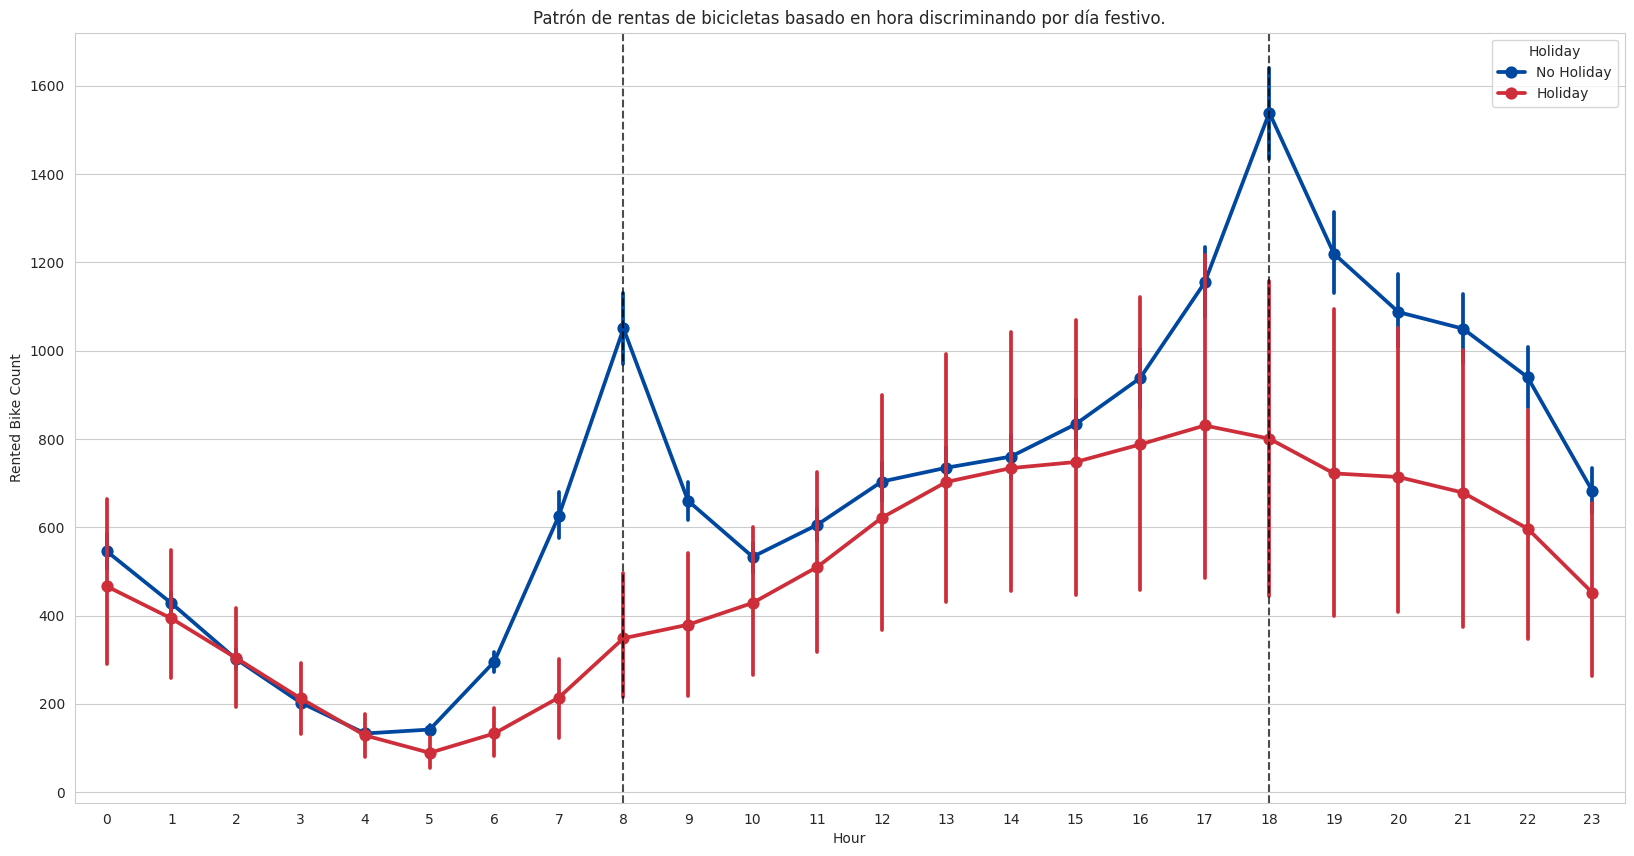

In [66]:
plt.figure(figsize=(20,10))
sns.pointplot(x=seoul_bike_sharing_demand_df['Hour'],
              y=seoul_bike_sharing_demand_df['Rented Bike Count'],
              hue=seoul_bike_sharing_demand_df['Holiday'],
              palette={"Holiday": "#CD2E3A", "No Holiday": "#0047A0"})
plt.title("Patrón de rentas de bicicletas basado en hora discriminando por día festivo.")

# Add vertical lines at hour 8 and hour 18
plt.axvline(x=8, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
plt.axvline(x=18, color='black', linestyle='--', linewidth=1.5, alpha=0.7)

plt.show()

Observaciones de la gráfica de arriba serían:
- En días no festivos los picos se encuentran en las horas de entrada y salida de las oficinas.
- En días festivos no hay tales picos es una gráfica más suave que va disminuyendo conforme acaba el día.
Esta gráfica muestra una clara tendencia de uso para transportarse hacia desde los espacios de trabajo.

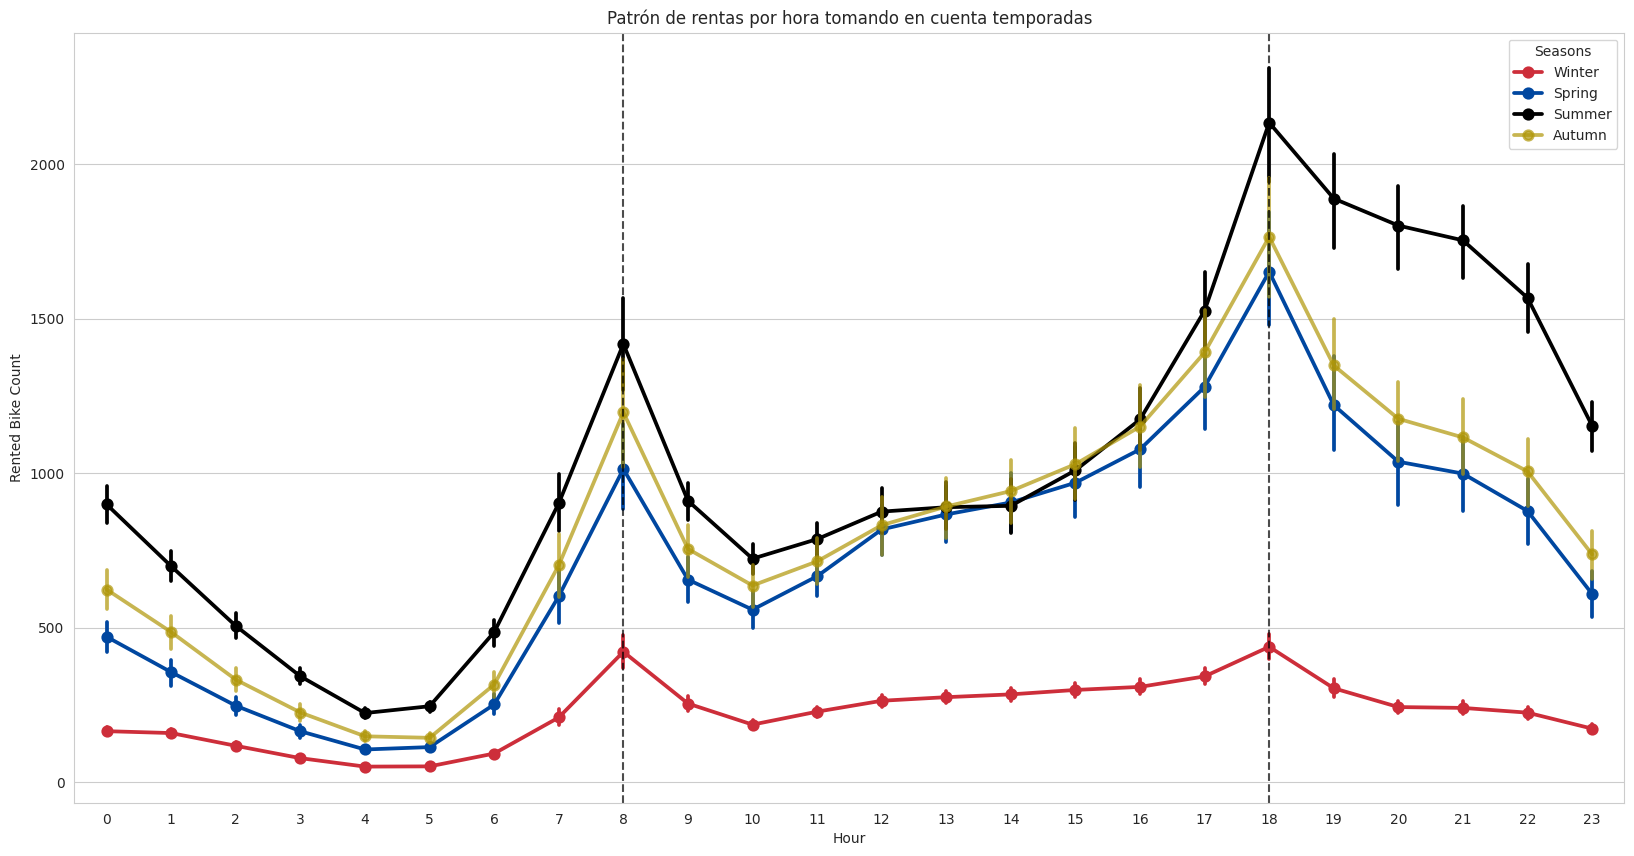

In [67]:
plt.figure(figsize=(20,10))

# South Korean flag colors (4 colors for 4 seasons)
# Order: red, blue, black, white – you can assign them to seasons as you prefer
seasons_palette = ["#CD2E3A", "#0047A0", "#000000", "#B09709B4"]

sns.pointplot(x=seoul_bike_sharing_demand_df['Hour'],
              y=seoul_bike_sharing_demand_df['Rented Bike Count'],
              hue=seoul_bike_sharing_demand_df['Seasons'],
              palette=seasons_palette)

plt.title("Patrón de rentas por hora tomando en cuenta temporadas")
plt.axvline(x=8, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
plt.axvline(x=18, color='black', linestyle='--', linewidth=1.5, alpha=0.7)
plt.show()

Observaciones:
- Los picos permacen pero en invierno la gente renta menos bicicletas (debido a que son condiciones más adversas para rodar)
- En verano y otoño se rentan más.